# 서울 지하철 이용자 예측 회귀 모델링 (하이퍼파라미터 튜닝 버전)
> 목표: 검증 손실(Val Loss) 0.05 미만 달성
> 튜닝 항목: 학습률, 에폭, 은닉층 뉴런 수, 드롭아웃 비율, LR 스케줄러 추가

# 0. 라이브러리 불러오기

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

# 미니배치 학습을 위한 DataLoader
from torch.utils.data import TensorDataset, DataLoader

# [튜닝 변경] ReduceLROnPlateau 대신 CosineAnnealingWarmRestarts 사용
# ReduceLROnPlateau: LR이 한 번 줄면 다시 안 올라감 → 300 에폭 이후 val loss 개선 없음
# CosineAnnealingWarmRestarts: 주기적으로 LR을 다시 올려줌(warm restart) → 지역 최솟값 탈출 가능
# 기존: from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)


사용 장치: cpu


# 1. 데이터 로드

In [87]:
# [튜닝 수정] 실제 데이터 파일 경로로 변경
# 기존: pd.read_csv("subway_train.csv")
# 기존: pd.read_csv("subway_test.csv")
train_df = pd.read_csv("subway_train.csv")
test_df = pd.read_csv("subway_test.csv")

# 데이터 앞 5행 확인
print(train_df.head())

# 데이터 구조 확인
print(train_df.info())

# 결측치 확인
print(train_df.isnull().sum())


         date day_of_week  month     station_name  visibility  precipitation  \
0  2023-01-01      Sunday      1   Jamsil Station    9.047399       2.136081   
1  2023-01-03      Friday      1  Hongdae Station   13.319895      16.647143   
2  2023-01-04      Sunday      1   Sillim Station   12.551289      18.386217   
3  2023-01-06      Friday      1  Hongdae Station    5.350641      19.170438   
4  2023-01-07      Friday      1    Seoul Station    8.592605       8.924651   

   temperature  num_people  
0    18.023113       13075  
1    11.032550       12454  
2    12.342243       10093  
3    30.787836       13413  
4    -0.677078       10889  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           900 non-null    object 
 1   day_of_week    900 non-null    object 
 2   month          900 non-null    int64  
 3   station_name   8

# 2. 결측치 처리

In [88]:
# visibility 결측치는 평균값으로 채움
train_df["visibility"] = train_df["visibility"].fillna(train_df["visibility"].mean())

# station_name 결측치는 unknown으로 채움
train_df["station_name"] = train_df["station_name"].fillna("unknown")

# 결측치 처리 결과 확인
print(train_df.isnull().sum())

date             0
day_of_week      0
month            0
station_name     0
visibility       0
precipitation    0
temperature      0
num_people       0
dtype: int64


# 3. 변수 정의

In [89]:
# 학습에 사용하지 않을 컬럼
COL_DEL = ["date"]

# 수치형 입력 변수
COL_NUM = ["visibility", "precipitation", "temperature"]

# 범주형 입력 변수
COL_CAT = ["day_of_week", "month", "station_name"]

# 예측 대상 컬럼
COL_Y = "num_people"

# 4. 간단한 데이터 시각화

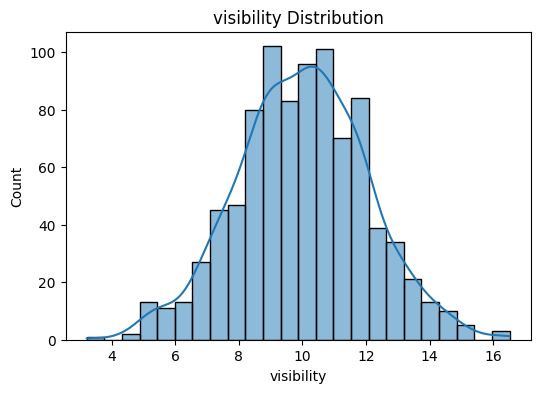

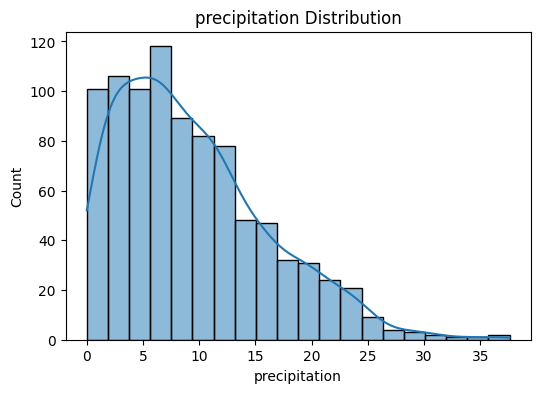

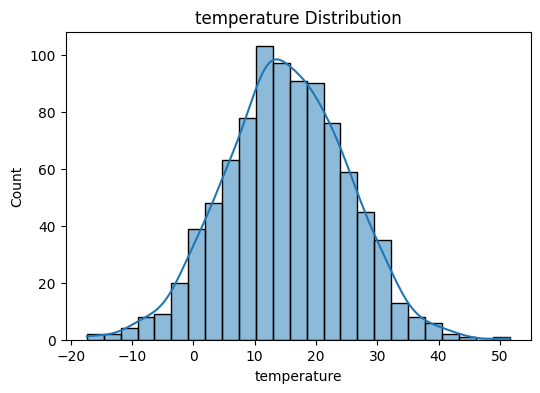

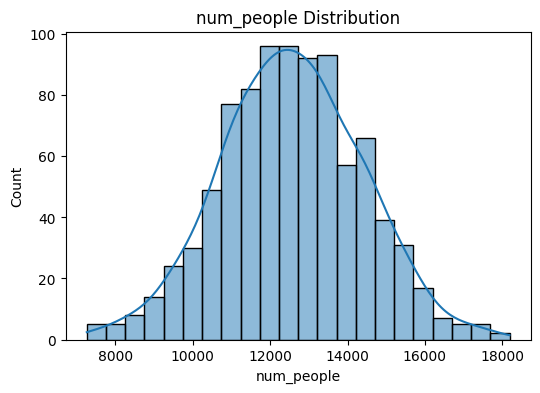

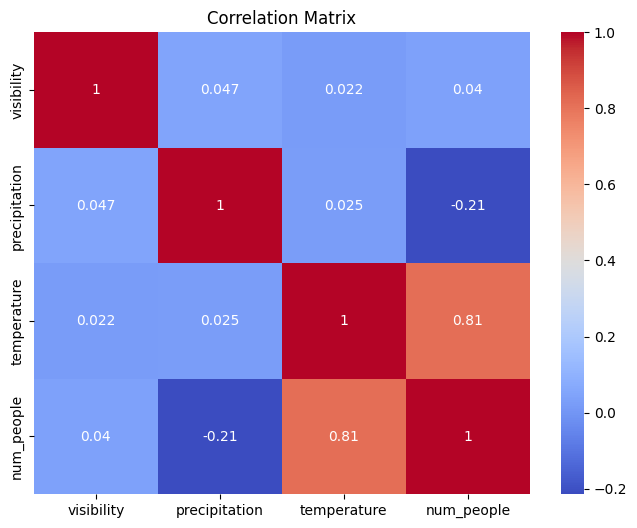

In [90]:
# 수치형 변수 분포 확인
for col in COL_NUM:
    plt.figure(figsize=(6, 4))
    sns.histplot(train_df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

# 목표값 분포 확인
plt.figure(figsize=(6, 4))
sns.histplot(train_df[COL_Y], kde=True)
plt.title("num_people Distribution")
plt.show()

# 상관관계 확인
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[COL_NUM + [COL_Y]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 5. 이상값 처리 함수

In [91]:
def handle_outliers_iqr(df, col):
    # 1사분위수
    q1 = df[col].quantile(0.25)

    # 3사분위수
    q3 = df[col].quantile(0.75)

    # IQR 계산
    iqr = q3 - q1

    # 하한값
    lower_bound = q1 - 1.5 * iqr

    # 상한값
    upper_bound = q3 + 1.5 * iqr

    # 하한보다 작은 값은 하한으로 변경
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

    # 상한보다 큰 값은 상한으로 변경
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    return df


# 수치형 변수에 이상값 처리 적용
for col in COL_NUM:
    train_df = handle_outliers_iqr(train_df, col)

# 6. 범주형 변수 라벨 인코딩

In [92]:
# [변경] LabelEncoder → pd.get_dummies() 원-핫 인코딩
#
# 기존 방식 (LabelEncoder):
#   station_name: 강남=0, 홍대=1, 신촌=2 ...
#   → 모델이 숫자 크기에 의미를 부여해 "강남(0)과 홍대(1)는 비슷하다"고 잘못 학습
#
# 원-핫 인코딩:
#   station_name_강남, station_name_홍대, station_name_신촌 ... (각각 0/1 컬럼)
#   → 역 간 순서/거리 관계가 없으므로 모델이 각 역을 독립적으로 학습 가능
#
# 기존 코드:
# label_encoders = {}
# for col in COL_CAT:
#     le = LabelEncoder()
#     train_df[col] = le.fit_transform(train_df[col].astype(str))
#     label_encoders[col] = le

train_df = pd.get_dummies(train_df, columns=COL_CAT, dtype=float)

print(f"원-핫 인코딩 후 전체 컬럼 수: {len(train_df.columns)}")
print(f"station_name 더미 컬럼 수: {len([c for c in train_df.columns if c.startswith('station_name_')])}")
print(train_df.head())


원-핫 인코딩 후 전체 컬럼 수: 30
station_name 더미 컬럼 수: 6
         date  visibility  precipitation  temperature  num_people  \
0  2023-01-01    9.047399       2.136081    18.023113       13075   
1  2023-01-03   13.319895      16.647143    11.032550       12454   
2  2023-01-04   12.551289      18.386217    12.342243       10093   
3  2023-01-06    5.350641      19.170438    30.787836       13413   
4  2023-01-07    8.592605       8.924651    -0.677078       10889   

   day_of_week_Friday  day_of_week_Monday  day_of_week_Saturday  \
0                 0.0                 0.0                   0.0   
1                 1.0                 0.0                   0.0   
2                 0.0                 0.0                   0.0   
3                 1.0                 0.0                   0.0   
4                 1.0                 0.0                   0.0   

   day_of_week_Sunday  day_of_week_Thursday  ...  month_9  month_10  month_11  \
0                 1.0                   0.0  ...      0

# 6. 범주형 변수 원-핫 인코딩

In [93]:
# 입력값 스케일러
x_scaler = StandardScaler()

# 수치형 컬럼을 평균 0, 표준편차 1로 변환
train_df[COL_NUM] = x_scaler.fit_transform(train_df[COL_NUM])

# 목표값 스케일러
# 회귀 모델에서는 y 값도 스케일링하면 학습이 안정적임
y_scaler = StandardScaler()

train_df[[COL_Y]] = y_scaler.fit_transform(train_df[[COL_Y]])

# 8. 학습 데이터와 검증 데이터 분리

In [94]:
# 입력 데이터 X 생성
X = train_df.drop(COL_DEL + [COL_Y], axis=1)

# 정답 데이터 y 생성
y = train_df[[COL_Y]]

# 학습용 80%, 검증용 20%로 분리
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (720, 28)
X_val shape: (180, 28)
y_train shape: (720, 1)
y_val shape: (180, 1)


# 9. PyTorch Tensor 변환

In [95]:
# 입력 데이터는 실수형 float32로 변환
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)

# 정답 데이터도 회귀 문제이므로 float32 사용
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([720, 28])
y_train_tensor: torch.Size([720, 1])


# 10. PyTorch 회귀 모델 정의

In [96]:
class SubwayRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # [튜닝] 뉴런 수 확대 (기존: 64)
        # self.fc1 = nn.Linear(input_dim, 128)
        self.fc1 = nn.Linear(input_dim, 64)

        # [튜닝] 뉴런 수 확대 (기존: 32)
        # self.fc2 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 32)

        # [튜닝] 뉴런 수 확대 (기존: 16)
        # self.fc3 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 8)

        # 출력층 (기존: 16 → 1)
        # self.output = nn.Linear(32, 1)
        self.output = nn.Linear(8, 1)

        self.relu = nn.ReLU()

        # [튜닝] Dropout 비율 (기존: 0.2 ← 원본, 0.1 ← 1차)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        # [튜닝] fc2 이후에도 Dropout 적용 (기존: fc1 이후에만 적용)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.relu(self.fc3(x))
        x = self.output(x)
        return x


input_dim = X_train.shape[1]
model = SubwayRegressionModel(input_dim).to(device)
print(model)


SubwayRegressionModel(
  (fc1): Linear(in_features=28, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


# 11. 손실 함수와 최적화 함수 설정

In [97]:
criterion = nn.MSELoss()

# [튜닝] 학습률
# 0.003 정도가 빠른 수렴 + 안정성 균형점
# 기존: lr=0.001, weight_decay=1e-3  ← 2차 튜닝값
# 기존: lr=0.00005, weight_decay=1e-2 ← 3 시도값
# optimizer = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-2)
optimizer = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-2)

# [튜닝 변경] CosineAnnealingWarmRestarts로 교체
# T_0=200: 200 에폭마다 LR이 최솟값(eta_min)에서 최댓값(lr)으로 리셋됨
# T_mult=1: 매 주기 길이 동일
# eta_min=1e-5: LR의 최솟값
# 효과: LR이 내려갔다가 다시 올라가며 지역 최솟값에서 탈출 → val loss 계속 개선 가능
# 기존: ReduceLROnPlateau(patience=150) ← 2차 튜닝값 (LR이 내려가기만 함)
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=200,
    T_mult=1,
    eta_min=1e-5
)


# 12. 모델 학습

In [98]:
# [튜닝] 에폭 증가: CosineAnnealing 주기(200)가 여러 번 돌아야 효과가 남
# 기존: epochs=1000  ← 2차 튜닝값
epochs = 2000

# [튜닝] 배치 사이즈 축소: 작을수록 배치 노이즈 많아져 정규화 효과 강함
# 기존: batch_size=64  ← 2차 튜닝값
# batch_size = 8
batch_size = 16

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_loss_history = []
val_loss_history = []
lr_history = []

for epoch in range(epochs):
    model.train()

    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    avg_train_loss = sum(batch_losses) / len(batch_losses)
    train_loss_history.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)
    val_loss_history.append(val_loss.item())

    # [튜닝 변경] CosineAnnealingWarmRestarts는 epoch 번호를 전달
    # ReduceLROnPlateau처럼 손실값을 넣지 않음
    # 기존: scheduler.step(val_loss.item())  ← ReduceLROnPlateau 방식
    scheduler.step(epoch)

    lr_history.append(optimizer.param_groups[0]['lr'])

    if (epoch + 1) % 200 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {val_loss.item():.6f} "
            f"LR: {current_lr:.6f}"
        )


Epoch [200/2000] Train Loss: 0.437320 Val Loss: 0.426107 LR: 0.000010
Epoch [400/2000] Train Loss: 0.243653 Val Loss: 0.211001 LR: 0.000010
Epoch [600/2000] Train Loss: 0.217012 Val Loss: 0.176360 LR: 0.000010
Epoch [800/2000] Train Loss: 0.202735 Val Loss: 0.163425 LR: 0.000010
Epoch [1000/2000] Train Loss: 0.191495 Val Loss: 0.156359 LR: 0.000010
Epoch [1200/2000] Train Loss: 0.176256 Val Loss: 0.152416 LR: 0.000010
Epoch [1400/2000] Train Loss: 0.168629 Val Loss: 0.150449 LR: 0.000010
Epoch [1600/2000] Train Loss: 0.172075 Val Loss: 0.149720 LR: 0.000010
Epoch [1800/2000] Train Loss: 0.161663 Val Loss: 0.148702 LR: 0.000010
Epoch [2000/2000] Train Loss: 0.154408 Val Loss: 0.148940 LR: 0.000010


# 13. 검증 데이터 평가

In [99]:
# 평가 모드
model.eval()

with torch.no_grad():
    # 검증 데이터 예측
    val_pred_scaled = model(X_val_tensor)

# Tensor를 NumPy 배열로 변환
val_pred_scaled = val_pred_scaled.cpu().numpy()
y_val_scaled = y_val_tensor.cpu().numpy()

# 스케일링된 예측값을 원래 이용자 수 단위로 복원
val_pred_original = y_scaler.inverse_transform(val_pred_scaled)

# 실제값도 원래 이용자 수 단위로 복원
y_val_original = y_scaler.inverse_transform(y_val_scaled)

# MSE 계산
mse = mean_squared_error(y_val_original, val_pred_original)

# R2 Score 계산
r2 = r2_score(y_val_original, val_pred_original)

print("PyTorch Regression Model")
print("MSE:", mse)
print("R2 Score:", r2)

PyTorch Regression Model
MSE: 496633.875
R2 Score: 0.8600636720657349


# 14. 학습 손실 시각화

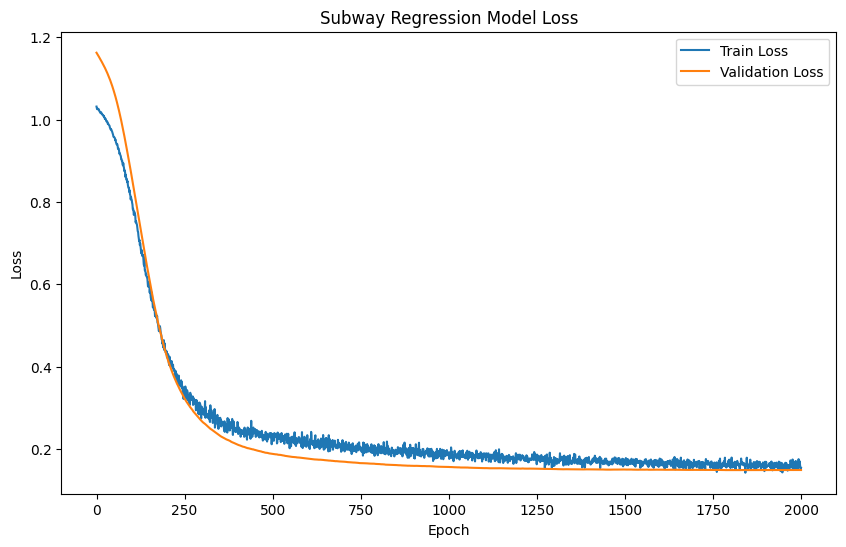

In [100]:
plt.figure(figsize=(10, 6))

# 학습 손실 그래프
plt.plot(train_loss_history, label="Train Loss")

# 검증 손실 그래프
plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Subway Regression Model Loss")
plt.legend()
plt.show()

# 15. 실제값과 예측값 비교 시각화

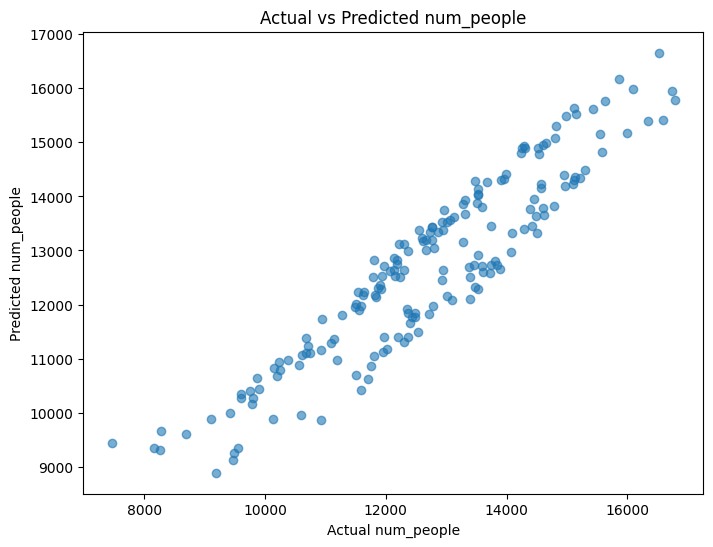

In [101]:
plt.figure(figsize=(8, 6))

# 실제값과 예측값 산점도
plt.scatter(y_val_original, val_pred_original, alpha=0.6)

plt.xlabel("Actual num_people")
plt.ylabel("Predicted num_people")
plt.title("Actual vs Predicted num_people")
plt.show()

# 테스트 데이터 복사

In [102]:
test_processed = test_df.copy()

# 결측치 처리
test_processed["visibility"] = test_processed["visibility"].fillna(test_processed["visibility"].mean())
test_processed["station_name"] = test_processed["station_name"].fillna("unknown")

# [변경] 원-핫 인코딩 (기존: label_encoders[col].transform() 사용)
# 기존:
# for col in COL_CAT:
#     test_processed[col] = label_encoders[col].transform(test_processed[col])
test_processed = pd.get_dummies(test_processed, columns=COL_CAT, dtype=float)

# 수치형 컬럼 스케일링
test_processed[COL_NUM] = x_scaler.transform(test_processed[COL_NUM])

# [변경] train과 동일한 컬럼 구조로 정렬
# train에 있지만 test에 없는 역 컬럼 → 0으로 채움
# test에 있지만 train에 없는 역 컬럼 → 제거
# 기존: label_encoders가 이 역할을 했으나 원-핫 인코딩에서는 직접 정렬 필요
test_processed = test_processed.reindex(
    columns=list(COL_DEL) + ([COL_Y] if COL_Y in test_processed.columns else []) + list(X_train.columns),
    fill_value=0
)

print("test_processed shape:", test_processed.shape)


test_processed shape: (300, 30)


# 17. 테스트 데이터 예측

In [103]:
# test 데이터에 num_people 컬럼이 있으면 평가 가능
has_target = COL_Y in test_processed.columns

if has_target:
    y_test = test_processed[[COL_Y]]

# [변경] 원-핫 인코딩 후 컬럼 정렬이 test_processed에 이미 적용됨
# X_train.columns 기준으로 선택 (기존: .drop()으로 불필요 컬럼 제거)
# 기존:
# X_test = test_processed.drop(COL_DEL + [COL_Y], axis=1)
X_test = test_processed[X_train.columns]

# Tensor 변환
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)

# 예측
model.eval()

with torch.no_grad():
    test_pred_scaled = model(X_test_tensor)

# 예측값을 원래 단위로 복원
test_pred_original = y_scaler.inverse_transform(test_pred_scaled.cpu().numpy())

print(test_pred_original[:10])


[[12095.46 ]
 [11869.473]
 [12464.023]
 [13536.905]
 [13989.47 ]
 [12761.499]
 [13082.231]
 [12126.544]
 [10645.575]
 [14190.77 ]]


# 18. 테스트 데이터에 실제 정답이 있는 경우 평가

In [104]:
if has_target:
    # test 데이터의 실제값은 원래 단위라고 가정
    y_test_original = y_test.values

    # MSE 계산
    test_mse = mean_squared_error(y_test_original, test_pred_original)

    # R2 Score 계산
    test_r2 = r2_score(y_test_original, test_pred_original)

    print("Test MSE:", test_mse)
    print("Test R2 Score:", test_r2)

Test MSE: 522451.3125
Test R2 Score: 0.8330754637718201


# 19. 예측 결과 저장

In [105]:
# 결과 저장용 데이터프레임 생성
result_df = test_df.copy()

# 예측 이용자 수 컬럼 추가
result_df["predicted_num_people"] = test_pred_original

# CSV 파일로 저장
result_df.to_csv("subway_pytorch_prediction.csv", index=False)

print("subway_pytorch_prediction.csv 파일이 생성되었습니다.")
print(result_df.head())

subway_pytorch_prediction.csv 파일이 생성되었습니다.
         date day_of_week  month     station_name  visibility  precipitation  \
0  2023-02-01   Wednesday      2  Hongdae Station    8.181270       8.811098   
1  2023-02-02   Wednesday      2  Gangnam Station   10.057751      18.851489   
2  2023-02-03      Friday      2   Jamsil Station    9.895961      11.771597   
3  2023-02-04   Wednesday      2   Sillim Station   13.283054       1.346370   
4  2023-02-05   Wednesday      2   Sillim Station    9.832798       4.033435   

   temperature  num_people  predicted_num_people  
0    11.411536       11475          12095.459961  
1    15.566285       12683          11869.472656  
2    16.331512       11908          12464.023438  
3    18.014205       12953          13536.905273  
4    22.576629       13322          13989.469727  
